# Histogram

- Vizualizace rozdělení dat. Skládá se z binů (intervalů, kategorií) a četností (počtů) událostí (také se říká eventů), které do každé přihrádky spadají.

- V příkladu níže připravíme vzorek 1000 eventů "vylosovaných" z normálního rozdělení a z nich vytvoříme histogram.

In [ ]:
import numpy as np

# Vytvoříme testovací data (1000 náhodných bodů)
data = np.random.normal(loc = 0, scale = 10, size = 1000)

# Vypočítáme histogram
counts, bin_edges = np.histogram(data, bins = 10)
print("Counts:", counts)
print("Bin edges:", bin_edges)


- Často nám stačí histogram skutečně jenom zobrazit. Pak nepotřebujeme `np.histogram` a můžeme použít rovnou malovací funkci `matplotlib.pyplot.hist`.

In [ ]:
# Vykreslíme histogram jen s pomocí matplotlib
import matplotlib.pyplot as plt
plt.hist(data, bins = 10)
plt.title('Histogram of Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


- Histogramy lze normalizovat tak, aby zobrazovaly hustotu pravděpodobnosti místo četnosti, což umožňuje jejich porovnání s hustotami pravděpodobnosti (PDF).

    - Normalizace je provedena tak, aby plocha pod histogramem byla rovna 1. Tím se histogram stane hustotou pravděpodobnosti.

    - Chcete-li histogram tímto způsobem normalizovat, musíte počet eventů v každém binu vydělit:

        - celkovým počtem eventů v histogramu a

        - šířkou binu (neboli délkou příslušného intervalu).

    - `matplotlib.pyplot.hist()` má parametr `density`, který při nastavení na `True` takto histogram normalizuje.


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Vykreslíme histogram normalizovaný na hustotu pravděpodobnosti
plt.hist(data, bins = 10, density = True, label = 'Histogram')

# Vykreslíme skutečnou PDF, ze které byla data vygenerována
x = np.linspace(-50, 50, 1000)
pdf = norm.pdf(x, loc = 0, scale = 10)
plt.plot(x, pdf, color = 'red', label = 'PDF')

plt.title('Histogram of Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


- Histogram není vždy nutné nejprve vytvořit; lze ho vykreslit přímo z dat.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(loc = 0, scale = 10, size = 1000)
plt.hist(data, bins = 20, range = (-50, 50), density = True, label = 'Histogram')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.legend()
plt.show()

# plt.hist(data, bins = [-30, -20, -15, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 15, 20, 30], density = True)
# plt.hist(data, bins = 10, density = True)

# Poznámka: excelentní implementace histogramu

- Pokud potřebujete speciální funkce, jako jsou 

    - výpočet statistické neurčitosti histogramů s váhovanými eventy,

    - sčítání histogramů pomocí operátoru `+`, `h1 + h2`,

    - slicing histogramů, rebinning a projekce,

  pak je potřeba použít balíček `hist`, který je skvělou implementací histogramů v Pythonu. Poskytuje širokou škálu funkcí a je optimalizován na výkon a uživatelské pohodlí.


# Matematika histogramů

- Pro spojité náhodné proměnné lze histogramy použít k aproximaci funkce hustoty pravděpodobnosti (PDF) dané proměnné.

- Střední hodnotu histogramu v binu vymezeném intervalem [a, b] lze vypočítat jako:
    $$
    E[X] = \int_a^b f(x) \, dx
    $$
  kde f(x) je PDF dané proměnné.

- Obrázek níže ukazuje souvislost mezi histogramem a PDF spojité náhodné proměnné. Plocha pod histogramem v intervalu [a, b] odpovídá pravděpodobnosti, že proměnná nabyde hodnoty v tomto intervalu.


In [ ]:
# Vykreslíme obrázek znázorňující vzorec pro střední hodnotu histogramu v přihrádce vymezené intervalem [a, b]
#   - PDF f(x) je vykreslena modře a plocha pod křivkou mezi a a b je zbarvena světle modře
#   - body a a b jsou označeny na ose x a interval [a, b] je označen oboustrannou šipkou
#   - vzorec pro střední hodnotu histogramu v přihrádce je napsán černě
#   - histogram je vykreslen jako schodová funkce; obsah každé přihrádky je vypočítán jako integrál PDF přes interval přihrádky a výška schodové funkce se rovná obsahu přihrádky vydělenému šířkou přihrádky.

x = np.linspace(-30, 30, 10000)
pdf = norm.pdf(x, loc = 0, scale = 10)
plt.plot(x, pdf, color = 'blue', label = r'$f(x)$')
plt.fill_between(x, pdf, where = (x >= 0) & (x <= 10), color = 'lightblue', alpha = 0.5, label = r'$\int_{0}^{10} f(x) \mathrm{d}x$')
bin_edges = np.arange(-30, 31, 10)
bin_contents = [np.trapezoid(pdf[(x >= bin_edges[i]) & (x < bin_edges[i + 1])], x[(x >= bin_edges[i]) & (x < bin_edges[i + 1])]) for i in range(len(bin_edges) - 1)]
bin_widths = np.diff(bin_edges)
bin_heights = bin_contents / bin_widths
plt.step(bin_edges[:-1], bin_heights, where = 'post', color = 'orange', label = 'Histogram')

plt.text(5, 0.0299, r'$\int_{0}^{10} f(x) \mathrm{d}x$', fontsize = 12, ha = 'center', va = 'bottom', color = 'orange')
plt.title('Correspondence between PDF and histogram')
plt.xlabel(r'$x$')
plt.ylabel('Probability Density')
plt.legend()
# set the y-axis minimum to 0
plt.ylim(bottom = 0)
plt.show()


# Histogramy a diskrétní náhodné proměnné

- U diskrétní náhodné proměnné histogram reprezentuje tzv. probability mass function (PMF) dané proměnné, která udává pravděpodobnost každého možného výsledku.

- Příklady diskrétních náhodných proměnných zahrnují:

    - S. D. Poisson: počet nesprávných soudních rozsudků v dané zemi za daný časový interval,

    - S. Newcombe: počet hvězd nalezených v jednotce prostoru,

    - L. Bortkiewicz: počet pruských vojáků náhodně zabitých kopnutím koně v daném sboru pruské armády a daném roce.

        - 14 sborů sledovaných po dobu 20 let, celkem 280 sbor-roků (eventů)

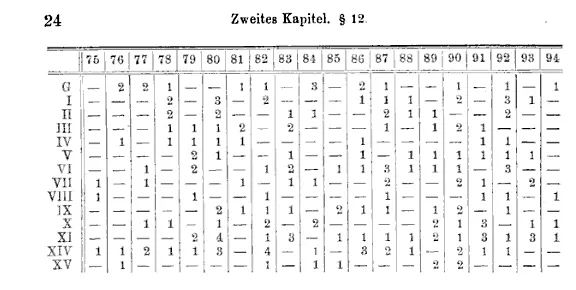


In [ ]:
# Vykreslíme data sebraná Bortkiewiczem o počtu pruských vojáků náhodně zabitých kopnutím koně
# za daný časový interval v daném sboru - nakreslíme odpovídající histogram. Data jsou následující:
#   - 0 zabitých vojáků: 144 krát
#   - 1 zabitý voják:     91 krát
#   - 2 zabití vojáci:    32 krát
#   - 3 zabití vojáci:    11 krát
#   - 4 zabití vojáci:     2 krát
data = np.array([0] * 144 + [1] * 91 + [2] * 32 + [3] * 11 + [4] * 2)
plt.hist(data, bins = np.arange(-0.5, 5.5, 1), density = False, label = 'Data')
plt.xlabel('Number of soldiers killed')
plt.ylabel('Number of events')
plt.title('Histogram of Bortkiewicz data')
plt.legend()
plt.show()


In [ ]:
# Nafitujeme Poissonovo rozdělení na data a vykreslíme odpovídající PDF na stejném obrázku jako histogram.
# Parametr Poissonova rozdělení lze odhadnout jako střední hodnotu Bortkiewiczova vzorku dat.
from scipy.stats import poisson
lambda_ = np.mean(data)
x = np.linspace(0, 4, 5)
pdf = poisson.pmf(x, mu = lambda_)
plt.hist(data, bins = np.linspace(-0.5, 4.5, 6), density = True, label = 'Data')
# Vykreslíme Poissonovu PMF jako schodovou funkci. Funkce začíná na x = -0,5
# a výška schodové funkce v x = k se rovná hodnotě
# Poissonovy PMF v x = k pro k = 0, 1, 2, 3, 4.
plt.step(x - 0.5, pdf, where = 'post', color = 'red', label = 'Poisson fit')
plt.xlabel('Number of soldiers killed')
plt.ylabel('Probability')
plt.title('Histogram of Bortkiewicz data')
plt.legend()
plt.show()


# Obsah binu jako poissonovská náhodná proměnná

- Vezměme nafitovanou funkci z předchozí části a zkusme předpovědět výsledek experimentu s 280 eventy po vzoru Bortkiewicze.

- Očekávaný počet eventů s $k$ kopanci od koně, $\lambda_{k}$, je nafitované Poissonovo rozdělení vynásobené celkovým počtem eventů, tedy:
    $$
    \lambda_{k} = 280 \cdot \text{Poisson}(k; \lambda)
    $$

- Skutečný počet eventů s $k$ kopanci od koně, $n_{k}$, je náhodná proměnná sledující Poissonovo rozdělení se střední hodnotou $\lambda_k$, tedy:
    $$
    n_k \sim \text{Poisson}(n_k; \lambda_k)
    $$

    - Poznámka: přesné rozdělení všech proměnných $n_k$ je multinomické, ale Poissonovo rozdělení použijeme jako aproximaci, protože si lze snadno zapamatovat, že "počet eventů v binu je Poissonova náhodná proměnná se střední hodnotou rovnou očekávanému počtu eventů v daném binu". Přísně vzato je počet eventů v binu Poissonovou náhodnou proměnnou pouze tehdy, pokud není celkový počet eventů pevně stanoven. Nicméně to je dobrá aproximace v situacích, kdy je celkový počet eventů "velký".


# Dobrovolná úloha: statistická neurčitost binů histogramu

- Jedním ze způsobů, jak porovnat histogram s nafitovanou funkcí, je vypočítat statistickou neurčitost obsahů binů histogramu a zkontrolovat, zda nafitovaná funkce je kompatibilní s histogramem v rámci této neurčitosti.

    - Připomeňme, že počet eventů v binu lze považovat za Poissonovu náhodnou proměnnou. Statistickou neurčitost obsahu binu s $n$ eventy tedy lze odhadnout jako $\sqrt{n}$.


# Dobrovolná úloha: test předpokladu Poissonova modelu pro Bortkiewiczova data

- Vyhodnoťte testovací statistiku $\chi^2$ pro Bortkiewiczova data a zkontrolujte, zda Poissonův model data dobře popisuje.

- Testovací statistiku $\chi^2$ lze vypočítat jako:
    $$
    \chi^2 = \sum_{k} \frac{(n_k - \lambda_k)^2}{\lambda_k}
    $$
    kde $n_k$ je pozorovaný počet eventů s $k$ kopanci od koně a $\lambda_k$ je očekávaný počet eventů s $k$ kopanci od koně podle nafitovaného Poissonova rozdělení. Zároveň $\lambda_k$ je rozptyl Poissonova rozdělení.

- Testovací statistika $\chi^2$ sleduje $\chi^2$ rozdělení s počtem stupňů volnosti rovným počtu binů minus počet nafitovaných parametrů minus 1. V tomto případě máme 5 binů (0, 1, 2, 3, 4) a nafitovali jsme 1 parametr (střední hodnotu Poissonova rozdělení), takže máme 5 - 1 - 1 = 3 stupně volnosti.

- Následně lze vypočítat p-hodnotu pro testovací statistiku $\chi^2$ a zkontrolovat, zda je větší než předdefinovaný confidence level (např. 0,05), abychom určili, zda Poissonův model data dobře popisuje.


# Dobrovolná úloha: test hypotézy pomocí pseudoexperimentů

- Dalším způsobem, jak otestovat předpoklad platnosti Poissonova modelu pro Bortkiewiczova data, je použití pseudoexperimentů.

- Nulová hypotéza je, že data sledují Poissonovo rozdělení s nafitovanou střední hodnotou.

- Můžeme vygenerovat velké množství pseudoexperimentů vzorkováním 280 hodnot z nafitovaného Poissonova rozdělení, sestavením histogramu a výpočtem testovací statistiky $\chi^2$ pro každý pseudoexperiment. Tímto způsobem lze sestavit rozdělení testovací statistiky $\chi^2$ za platnosti nulové hypotézy.

- Testovací statistiku $\chi^2$ z reálných dat pak lze porovnat s rozdělením testovací statistiky $\chi^2$ z pseudoexperimentů a vypočítat p-hodnotu pro nulovou hypotézu.


# Dobrovolná úloha: součet náhodných proměnných


- Vytvořte histogram součtu dvou náhodných proměnných X a Y, kde X a Y jsou nezávislé a stejně rozdělené (i.i.d.) náhodné proměnné s rovnoměrným rozdělením na intervalu [0, 1].

- Vzorkujte 1000 dvojic hodnot X a Y, vypočítejte jejich součet Z = X + Y a zobrazte histogram Z.

- Všimněte si, že součet má rozdělení dané konvolucí rozdělovacích funkcí proměnných X a Y. V našem případě se jedná o trojúhelníkové rozdělení na intervalu [0, 2]. Obecně platí:
    $$
    f_Z(z) = \int_{-\infty}^{\infty} f_X(x) f_Y(z - x) \, dx
    $$


# Centrální limitní věta

- Stručně řečeno: součet velkého počtu nezávislých a stejně rozdělených (i.i.d.) náhodných proměnných, z nichž každá má konečnou střední hodnotu a rozptyl, bude přibližně sledovat normální rozdělení, bez ohledu na původní rozdělení proměnných.


In [ ]:
# Příklad: součet 12 rovnoměrně rozdělených náhodných proměnných.
# Vykreslíme výsledný histogram spolu s normálním rozdělením se stejnou střední hodnotou a rozptylem.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
data = np.sum(np.random.uniform(low = 0, high = 1, size = (1000, 12)), axis = 1)
plt.hist(data, bins = 20, density = True, label = 'Histogram')
x = np.linspace(0, 12, 1000)
pdf = norm.pdf(x, loc = 6, scale = np.sqrt(12 / 12))
plt.plot(x, pdf, color = 'red', label = 'Normal fit')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Histogram of sum of 12 uniform random variables')
plt.legend()
plt.show()
